# EG-GenRM: Entropy-Guided Generative Verifiers for Mathematical Reasoning
**Ruimin Zhang (rz2737) · Menglei Zhang (mz3129) · Hantian Zhang (hz3101)**

---

## Table of Contents
| Part | Content |
|------|---------|
| 0 | Environment Setup & Global Config |
| 1 | Research Questions & Pipeline Overview |
| 2 | Data Loading & Quality Check |
| 3 | Baseline Evaluation |
| 4 | Teacher GenRM Candidate-Level Evaluation |
| 5 | Inference-Time Selection Strategy Comparison |
| 6 | Reasoning Error Analysis |
| 7 | SFT Data Construction |
| 8 | Method A — Standard QLoRA Verifier |
| 9 | Method B — EG-GenRM: Entropy-Masked QLoRA Verifier |
| 10 | Comprehensive Comparison & Ablation |
| 11 | Statistical Testing & Error Transition Analysis |
| 12 | Efficiency Analysis |
| 13 | Conclusions & Future Work |


## Part 0 · Environment Setup & Global Config

Install dependencies, import libraries, and set global path constants.
All paths are managed centrally in `PROJECT_CONFIG`.


In [4]:
# ── Install dependencies (Colab) ────────────────────────────────────────────
!pip install -q transformers datasets accelerate peft bitsandbytes safetensors


In [5]:
import json, random, warnings, os, re, gc, inspect
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('Imports OK')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Imports OK
GPU: NVIDIA A100-SXM4-40GB


In [6]:
# ── PROJECT_CONFIG: centralized path management ─────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT_CONFIG = {
    'project_dir':   '/content/drive/MyDrive/Colab Notebooks/5293-007/group_project',
    'json_path':     'teacher_outputs_all_candidates (38).jsonl',
    'baseline_dir':  'baseline/',
    'figures_dir':   'figures/',
    'results_dir':   'results/',
    'model_name':    'Qwen/Qwen2.5-1.5B-Instruct',
    'max_len':       1024,
    'entropy_top_k': 0.20,   # top-20% high-entropy completion tokens for EntropyMaskedLoss
}

os.chdir(PROJECT_CONFIG['project_dir'])
os.makedirs(PROJECT_CONFIG['figures_dir'], exist_ok=True)
os.makedirs(PROJECT_CONFIG['results_dir'], exist_ok=True)

# ── Shared utility functions ──────────────────────────────────────────────────
def normalize_answer(ans):
    """Lightweight answer normalization: strip LaTeX symbols, commas, etc."""
    if ans is None: return ''
    ans = str(ans).strip().lower()
    ans = ans.replace('$','').replace(',','').replace('\\','').strip()
    tokens = ans.split()
    if len(tokens) > 10:
        for tok in reversed(tokens):
            t = tok.strip('.,!?;:()')
            if t.replace('.','').replace('-','').replace('/','').isdigit(): return t
        return tokens[-1] if tokens else ''
    return ans

def save_fig(fname):
    path = os.path.join(PROJECT_CONFIG['figures_dir'], fname)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

def save_csv(df_or_dict, fname):
    path = os.path.join(PROJECT_CONFIG['results_dir'], fname)
    if isinstance(df_or_dict, dict): pd.DataFrame([df_or_dict]).to_csv(path, index=False)
    else: df_or_dict.to_csv(path, index=False)
    print(f'Saved: {path}')

def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): rows.append(json.loads(line))
    return rows

def write_jsonl(rows, path):
    with open(path, 'w', encoding='utf-8') as f:
        for r in rows: f.write(json.dumps(r, ensure_ascii=False) + '\n')
    print(f'Saved: {path}')

print('Config & utilities ready.')


Mounted at /content/drive
Config & utilities ready.


---
## Part 1 · Research Questions & Pipeline Overview

### Motivation
LLMs frequently generate reasoning chains that appear plausible but contain logical errors (Reasoning Hallucinations).
Errors tend to concentrate at a small number of critical decision nodes ("forking tokens") rather than being spread uniformly across the chain.

### Core Research Questions
| RQ | Question |
|----|----------|
| RQ1 | Can entropy signals identify high-risk reasoning steps within CoT traces? |
| RQ2 | Does EG-GenRM outperform CoT / Best-of-N / standard verifier baselines? |
| RQ3 | Can entropy-masked training improve efficiency under limited compute? |
| RQ4 | Which reasoning error types are most effectively captured by the proposed method? |

### Overall Pipeline
```
GSM8K / MATH500
       │
       ▼
Candidate Path Generation & Teacher GenRM Annotation
       │
       ▼
SFT Data Construction
       │
       ▼
Verifier Fine-tuning
[Method A: Standard QLoRA  /  Method B: Entropy-Masked QLoRA]
       │
       ▼
Inference-Time Selection Strategy
[Random / Majority Voting / Teacher-filtered / Fine-tuned Verifier]
       │
       ▼
Final Answer & Evaluation
```

### Team Responsibilities
| Member | Primary Role | Key Deliverables |
|--------|-------------|-----------------|
| Hantian Zhang | Data preparation & baselines | GSM8K/MATH500 candidate paths, Direct/CoT/Best-of-N baselines |
| Menglei Zhang | Candidate generation & intermediate experimental support | Candidate reasoning path pool |
| Ruimin Zhang | Fine-tuning, evaluation & integration | Method A/B verifier training, unified evaluation, comparison report |


---
## Part 2 · Data Loading & Quality Check

### 2.1 Data Source
The teacher output file contains verdicts generated by Kimi-K2.5 / DeepSeek-V3 on 4 candidate answers per question,
producing `parsed_final_verdict` (Yes/No).

**Key fields**:
| Field | Description |
|-------|-------------|
| `question_norm` | Normalized question text (used for grouping/deduplication) |
| `candidate_role` | correct\_1 / correct\_2 / subtle\_wrong / random\_wrong |
| `candidate_is_correct` | Ground truth label |
| `parsed_final_verdict` | Teacher verdict: Yes / No / None |
| `teacher_model` | Kimi-K2.5 or DeepSeek-V3 |


In [7]:
# ── Load raw data ────────────────────────────────────────────────────────────
JSON_PATH = PROJECT_CONFIG['json_path']
records = []
with open(JSON_PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line: records.append(json.loads(line))

df_all = pd.DataFrame(records)
print(f'Total records  : {len(df_all)}')
print(f'Columns ({len(df_all.columns)}): {list(df_all.columns)}')
print('\n=== candidate_role distribution ===')
print(df_all['candidate_role'].value_counts().to_string())
print('\n=== candidate_is_correct ===')
print(df_all['candidate_is_correct'].value_counts().to_string())
print('\n=== parsed_final_verdict (including None) ===')
print(df_all['parsed_final_verdict'].value_counts(dropna=False).to_string())
print('\n=== teacher_model ===')
print(df_all['teacher_model'].value_counts().to_string())


Total records  : 757
Columns (23): ['status', 'run_id', 'row_id', 'question_norm', 'question', 'candidate_role', 'candidate_is_correct', 'expected_answer', 'candidate_predicted_answer', 'candidate_solution_raw', 'candidate_solution_clean', 'reference_solution_raw', 'reference_solution_clean', 'teacher_model', 'teacher_prompt', 'answer_text', 'reasoning_text', 'finish_reason', 'parsed_final_verdict', 'earliest_error', 'usage', 'retry_count', 'timestamp']

=== candidate_role distribution ===
candidate_role
correct_1       190
correct_2       190
subtle_wrong    189
random_wrong    188

=== candidate_is_correct ===
candidate_is_correct
True     380
False    377

=== parsed_final_verdict (including None) ===
parsed_final_verdict
Yes     418
No      306
None     33

=== teacher_model ===
teacher_model
moonshotai/kimi-k2.5         713
deepseek-ai/deepseek-v3.2     44


### 2.2 Data Quality Check & Deduplication

**Anomalies found**:
- 1 question appears across 3 different `run_id` values → 7 candidates total (duplicated pipeline runs)
- 1 question has only correct\_1 / correct\_2, missing wrong candidates

**Fix strategy**: For each `question_norm`, retain the single `run_id` whose role set is most complete;
break ties by global `run_id` frequency.


In [8]:
# ── Raw grouping statistics ──────────────────────────────────────────────────
q_groups_raw = defaultdict(list)
for r in records:
    q_groups_raw[r['question_norm']].append(r)

raw_counts = Counter(len(v) for v in q_groups_raw.values())
print(f'Raw unique questions : {len(q_groups_raw)}')
print(f'Raw candidate distribution: {dict(sorted(raw_counts.items()))}')

REQUIRED_ROLES = {'correct_1', 'correct_2', 'subtle_wrong', 'random_wrong'}
print('\nAnomalous groups (candidate count ≠ 4):')
for qn, cands in q_groups_raw.items():
    if len(cands) != 4:
        print(f'  [{len(cands)} cands] runs={set(c["run_id"] for c in cands)}'
              f' roles={[c["candidate_role"] for c in cands]}')
        print(f'    q: {qn[:90]}')

Raw unique questions : 189
Raw candidate distribution: {2: 1, 4: 187, 7: 1}

Anomalous groups (candidate count ≠ 4):
  [7 cands] runs={'66e6b0b9', '324ff769', 'f673774a'} roles=['correct_1', 'correct_2', 'subtle_wrong', 'random_wrong', 'correct_1', 'correct_2', 'subtle_wrong']
    q: how many more digits does the base-3 representation of $987_{10}$ have than the base-8 rep
  [2 cands] runs={'c65cd6b7'} roles=['correct_1', 'correct_2']
    q: eric spent 2 hours removing wallpaper from just 1 wall of his 4 walled dining room. he als


In [9]:
# ── Dedup: retain the most complete run per question ─────────────────────────
run_global_freq = Counter(r['run_id'] for r in records)

def pick_best_run(cands):
    """Return candidates from the run_id with the most complete role set (tiebreak: global frequency)."""
    by_run = defaultdict(list)
    for c in cands: by_run[c['run_id']].append(c)
    def run_score(run_id):
        run_roles = {c['candidate_role'] for c in by_run[run_id]}
        return (len(run_roles & REQUIRED_ROLES), run_global_freq[run_id])
    best_run = max(by_run, key=run_score)
    return by_run[best_run]

q_groups_clean = {}
for qn, cands in q_groups_raw.items():
    q_groups_clean[qn] = pick_best_run(cands)

clean_counts = Counter(len(v) for v in q_groups_clean.values())
complete_qs   = {qn: v for qn, v in q_groups_clean.items() if len(v) == 4}
incomplete_qs = {qn: v for qn, v in q_groups_clean.items() if len(v) != 4}

print(f'Deduplicated unique questions: {len(q_groups_clean)}')
print(f'Candidate distribution: {dict(sorted(clean_counts.items()))}')
print(f'  Complete 4-candidate groups: {len(complete_qs)}')
print(f'  Incomplete (excluded): {len(incomplete_qs)}')
for qn, v in incomplete_qs.items():
    print(f'    {qn[:60]}  roles={[c["candidate_role"] for c in v]}')

# 重建 df_all
dedup_records = [c for cands in q_groups_clean.values() for c in cands]
df_all = pd.DataFrame(dedup_records)
print(f'\nFinal deduplicated records: {len(df_all)} | Complete groups: {len(complete_qs)}')

Deduplicated unique questions: 189
Candidate distribution: {2: 2, 3: 1, 4: 186}
  Complete 4-candidate groups: 186
  Incomplete (excluded): 3
    sean buys 3 cans of soda, 2 soups, and 1 sandwich. each soup  roles=['correct_2', 'subtle_wrong', 'random_wrong']
    rick took off on a road trip for the summer. he traveled to   roles=['subtle_wrong', 'random_wrong']
    eric spent 2 hours removing wallpaper from just 1 wall of hi  roles=['correct_1', 'correct_2']

Final deduplicated records: 751 | Complete groups: 186


### 2.3 Hantian Baseline Data Integration

Pre-computed baseline results from Hantian are stored in the `baseline/` directory and cover two standard benchmarks:

| File | Dataset | Content |
|------|---------|---------|
| `gsm8k_k5_run/direct_live.jsonl` | GSM8K 1000q | Direct (no CoT) predictions |
| `math500_k5_run/direct_live.jsonl` | MATH500 500q | Direct predictions |
| `math500_k5_run/candidate_paths.jsonl` | MATH500 500q × k=5 | CoT candidate paths |

> **Scope note**: Hantian baselines are evaluated on the full GSM8K/MATH500; Teacher/Fine-tuned methods are evaluated on the 186-question subset from teacher_outputs. The two scopes are **reported separately** and not directly compared.


In [10]:
BASELINE_DIR = os.path.join(PROJECT_CONFIG['project_dir'], PROJECT_CONFIG['baseline_dir'])

# ── GSM8K Direct ─────────────────────────────────────────────────────────────
gsm8k_rows = load_jsonl(os.path.join(BASELINE_DIR, 'gsm8k_k5_run', 'direct_live.jsonl'))
gsm8k_direct_acc = sum(
    normalize_answer(r['direct_prediction_raw']) == normalize_answer(r['direct_answer'])
    for r in gsm8k_rows) / len(gsm8k_rows)

# ── MATH500 Direct ───────────────────────────────────────────────────────────
math500_rows = load_jsonl(os.path.join(BASELINE_DIR, 'math500_k5_run', 'direct_live.jsonl'))
math500_direct_acc = sum(
    normalize_answer(r['direct_prediction_raw']) == normalize_answer(r['direct_answer'])
    for r in math500_rows) / len(math500_rows)

# ── MATH500 CoT / Majority / Best-of-N ──────────────────────────────────────
gold_math500 = {}
for l in open(os.path.join(BASELINE_DIR, 'math500_k5_run', 'cleaned_samples.jsonl')):
    if l.strip():
        r = json.loads(l)
        gold_math500[r['sample_id']] = normalize_answer(r.get('answer_normalized',''))

cp_by_q = defaultdict(list)
for l in open(os.path.join(BASELINE_DIR, 'math500_k5_run', 'candidate_paths.jsonl')):
    if l.strip():
        r = json.loads(l)
        r['is_correct'] = (
            normalize_answer(r.get('predicted_answer_normalized',''))
            == gold_math500.get(r['sample_id'], '__MISS__'))
        cp_by_q[r['sample_id']].append(r)

n_math500_q = len(cp_by_q)
math500_cot_pass1 = sum(
    any(c['is_correct'] for c in v if str(c.get('candidate_index','')) == '0')
    for v in cp_by_q.values()) / n_math500_q

rng_mv = random.Random(42)
math500_maj_correct = 0
for qid, cands in cp_by_q.items():
    gold = gold_math500.get(qid,'')
    vc = Counter(normalize_answer(c.get('predicted_answer_normalized','')) for c in cands)
    top = [a for a,v in vc.items() if v == max(vc.values())]
    if rng_mv.choice(top) == gold: math500_maj_correct += 1
math500_maj_acc = math500_maj_correct / n_math500_q
math500_bon_oracle = sum(any(c['is_correct'] for c in v) for v in cp_by_q.values()) / n_math500_q

print('=== Hantian Baseline Summary ===')
print(f'  Direct (no CoT) — GSM8K    : {gsm8k_direct_acc:.1%}  (n={len(gsm8k_rows)})')
print(f'  Direct (no CoT) — MATH500  : {math500_direct_acc:.1%}  (n={len(math500_rows)})')
print(f'  CoT pass@1 — MATH500       : {math500_cot_pass1:.1%}  (n={n_math500_q}q × k=5)')
print(f'  Majority Voting — MATH500  : {math500_maj_acc:.1%}')
print(f'  Best-of-N Oracle — MATH500 : {math500_bon_oracle:.1%}')


=== Hantian Baseline Summary ===
  Direct (no CoT) — GSM8K    : 97.8%  (n=1000)
  Direct (no CoT) — MATH500  : 81.6%  (n=500)
  CoT pass@1 — MATH500       : 63.8%  (n=500q × k=5)
  Majority Voting — MATH500  : 66.4%
  Best-of-N Oracle — MATH500 : 73.2%


---
## Part 3 · Baseline Evaluation

Evaluate three baselines on the 186 complete four-candidate questions to establish upper and lower accuracy bounds.

| Baseline | Strategy | Expected Accuracy |
|----------|----------|-------------------|
| **Random** | Pick 1 of 4 candidates at random | ≈50% (2 correct / 4 candidates) |
| **Majority Voting** | Vote by candidate answer | Reference without verifier |
| **Best-of-N Oracle** | Assume GT known; correct if any candidate is correct | 100% (theoretical upper bound) |


In [11]:
# ── 3a. Random Baseline (500 trials, take mean) ─────────────────────────────
def eval_random(q_groups, n_trials=500, seed=42):
    rng = random.Random(seed)
    accs = []
    for _ in range(n_trials):
        correct = sum(rng.choice(cands)['candidate_is_correct'] for cands in q_groups.values())
        accs.append(correct / len(q_groups))
    return np.mean(accs), np.std(accs)

random_mean, random_std = eval_random(complete_qs)
print(f'Random accuracy : {random_mean:.1%} ± {random_std:.1%}  (500 trials)')
print(f'  Expected ≈ 50%: 2 correct / 4 candidates per question')

Random accuracy : 50.0% ± 3.7%  (500 trials)
  Expected ≈ 50%: 2 correct / 4 candidates per question


In [12]:
# ── 3b. Best-of-N Oracle (upper bound) ──────────────────────────────────────
oracle_acc = sum(
    any(c['candidate_is_correct'] for c in cands)
    for cands in complete_qs.values()) / len(complete_qs)
print(f'Best-of-N Oracle : {oracle_acc:.1%}  (upper bound — requires Ground Truth)')

Best-of-N Oracle : 100.0%  (upper bound — requires Ground Truth)


In [13]:
# ── 3c. Majority Voting ─────────────────────────────────────────────────────
def eval_majority_voting(q_groups, seed=42):
    rng = random.Random(seed)
    correct = 0; details = []
    for qn, cands in q_groups.items():
        vote_counter = Counter()
        cand_by_ans  = defaultdict(list)
        for c in cands:
            a = normalize_answer(c.get('candidate_predicted_answer'))
            vote_counter[a] += 1; cand_by_ans[a].append(c)
        max_votes   = max(vote_counter.values())
        top_answers = [a for a,v in vote_counter.items() if v == max_votes]
        chosen_ans  = rng.choice(top_answers)
        chosen      = rng.choice(cand_by_ans[chosen_ans])
        is_correct  = bool(chosen['candidate_is_correct'])
        correct += int(is_correct)
        details.append({'question': qn, 'chosen_role': chosen['candidate_role'],
                        'is_correct': is_correct, 'vote_counts': dict(vote_counter)})
    return correct / len(q_groups), details

maj_acc, maj_details = eval_majority_voting(complete_qs)
ties = sum(1 for d in maj_details
           if len([v for v in d['vote_counts'].values()
                   if v == max(d['vote_counts'].values())]) > 1)
print(f'Majority Voting : {maj_acc:.1%}  ({ties}/{len(complete_qs)} ties)')

Majority Voting : 93.5%  (23/186 ties)


---
## Part 4 · Teacher GenRM Candidate-Level Evaluation

Using Kimi-K2.5 as the Teacher, each candidate's reasoning chain and answer is verified (Yes/No).
This part evaluates Teacher accuracy at the **candidate level** to establish a reference for downstream selection strategies.

> **Evaluation scope**: 718 valid verdict records (out of 751 total, excluding None)


In [14]:
# ── Teacher candidate-level metrics ─────────────────────────────────────────
df_v = df_all[df_all['parsed_final_verdict'].notna()].copy()
df_v['gt']   = df_v['candidate_is_correct'].astype(bool)
df_v['pred'] = df_v['parsed_final_verdict'].map({'Yes': True, 'No': False})

y_true = df_v['gt'].astype(int).values
y_pred = df_v['pred'].astype(int).values

overall_acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')

print(f'Records with verdict : {len(df_v)} / {len(df_all)}')
print(f'  Accuracy  : {overall_acc:.1%}')
print(f'  Precision : {p:.1%}')
print(f'  Recall    : {r:.1%}')
print(f'  F1        : {f1:.3f}')

print('\n--- Per-Role Breakdown ---')
per_role_rows = []
for role in ['correct_1','correct_2','subtle_wrong','random_wrong']:
    sub = df_v[df_v['candidate_role'] == role]
    if len(sub) == 0: continue
    acc_r = accuracy_score(sub['gt'].astype(int), sub['pred'].astype(int))
    p_r, r_r, f1_r, _ = precision_recall_fscore_support(
        sub['gt'].astype(int), sub['pred'].astype(int), average='binary', zero_division=0)
    print(f'  {role:<15}: acc={acc_r:.1%}  prec={p_r:.1%}  rec={r_r:.1%}  F1={f1_r:.3f}  n={len(sub)}')
    per_role_rows.append({'role':role,'accuracy':acc_r,'precision':p_r,'recall':r_r,'f1':f1_r,'n':len(sub)})

save_csv(pd.DataFrame(per_role_rows), 'verifier_per_role_metrics.csv')

Records with verdict : 718 / 751
  Accuracy  : 91.5%
  Precision : 87.9%
  Recall    : 97.1%
  F1        : 0.922

--- Per-Role Breakdown ---
  correct_1      : acc=97.3%  prec=100.0%  rec=97.3%  F1=0.986  n=187
  correct_2      : acc=96.8%  prec=100.0%  rec=96.8%  F1=0.984  n=187
  subtle_wrong   : acc=90.6%  prec=0.0%  rec=0.0%  F1=0.000  n=171
  random_wrong   : acc=80.3%  prec=0.0%  rec=0.0%  F1=0.000  n=173
Saved: results/verifier_per_role_metrics.csv


All Teachers (n=718)  acc=91.5%
            Pred:No  Pred:Yes
GT:Wrong        294        50
GT:Correct       11       363 

Kimi-only (n=674)  acc=91.7%
            Pred:No  Pred:Yes
GT:Wrong        273        49
GT:Correct        7       345 

Saved: figures/confusion_matrix_teacher.png


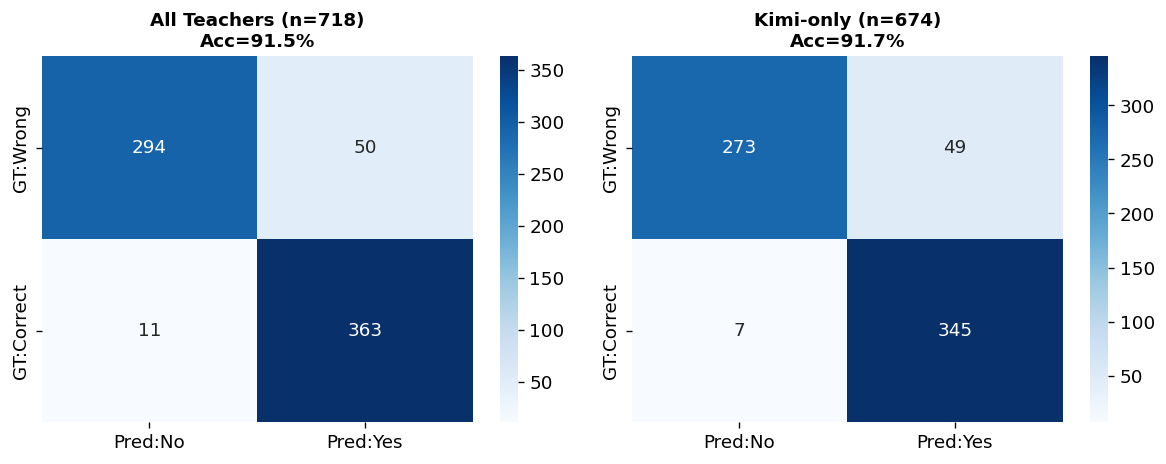

In [15]:
# ── Confusion matrix (All teachers vs Kimi-only) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, mask) in zip(axes, [
        ('All Teachers (n=718)', slice(None)),
        ('Kimi-only (n=674)',    df_v['teacher_model'].str.contains('kimi', case=False, na=False))]):
    sub = df_v[mask]
    cm  = confusion_matrix(sub['gt'].astype(int), sub['pred'].astype(int))
    acc_sub = accuracy_score(sub['gt'].astype(int), sub['pred'].astype(int))
    print(f'{label}  acc={acc_sub:.1%}')
    print(pd.DataFrame(cm, index=['GT:Wrong','GT:Correct'],
                       columns=['Pred:No','Pred:Yes']).to_string(), '\n')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred:No','Pred:Yes'], yticklabels=['GT:Wrong','GT:Correct'])
    ax.set_title(f'{label}\nAcc={acc_sub:.1%}', fontsize=11, fontweight='bold')
plt.tight_layout()
save_fig('confusion_matrix_teacher.png'); plt.show()

### Key Findings

- Teacher **high Recall (97.1%)**: almost never misses correct candidates (FN=11)
- Teacher **moderate Precision (87.9%)**: 50 False Positives (wrong candidates judged as correct)
- FP mainly from `random_wrong` (34 cases) and `subtle_wrong` (16 cases)
- **subtle_wrong FPR=9.4%, random_wrong FPR=19.7%** → this is the core challenge for the fine-tuned verifier and selection strategy to address


---
## Part 5 · Inference-Time Selection Strategy Comparison

Based on Teacher Yes/No verdicts, we design a progressive set of selection strategies.

```
Strategy progression:
  Random (50%) → Majority Voting (93.5%) → Teacher naive (?) → Teacher-filtered Majority (?)
```

**Core question**: Does Teacher naive outperform Majority Voting?


In [16]:
# ── Strategy 1: Teacher Naive ───────────────────────────────────────────────
# Strategy: randomly pick from Teacher-Yes pool; fallback to random if no Yes
def eval_teacher_naive(q_groups, seed=42):
    rng = random.Random(seed)
    correct = 0; strat_ct = Counter()
    for qn, cands in q_groups.items():
        yes_cands = [c for c in cands if c.get('parsed_final_verdict') == 'Yes']
        pool      = yes_cands if yes_cands else cands
        strategy  = 'teacher_yes' if yes_cands else 'random_fallback'
        chosen    = rng.choice(pool)
        strat_ct[strategy] += 1
        correct  += int(chosen['candidate_is_correct'])
    return correct / len(q_groups), dict(strat_ct)

teacher_naive_acc, teacher_naive_strats = eval_teacher_naive(complete_qs)
print(f'Teacher (naive) : {teacher_naive_acc:.1%}')
print(f'  Strategy breakdown: {teacher_naive_strats}')
print(f'\n  Teacher naive ({teacher_naive_acc:.1%}) < Majority Voting ({maj_acc:.1%})')
print('   Reason: Teacher Yes pool contains FPs; random selection introduces wrong candidates')

# FP / FN 统计
fp = df_v[(df_v['pred']==True)  & (~df_v['gt'])]
fn = df_v[(df_v['pred']==False) & ( df_v['gt'])]
print(f'\nFalse Positives (teacher=Yes, GT=Wrong) : {len(fp)}')
print(f'  by role: {dict(fp["candidate_role"].value_counts())}')
print(f'False Negatives (teacher=No, GT=Correct): {len(fn)}')
print(f'  by role: {dict(fn["candidate_role"].value_counts())}')

Teacher (naive) : 89.2%
  Strategy breakdown: {'teacher_yes': 186}

  Teacher naive (89.2%) < Majority Voting (93.5%)
   Reason: Teacher Yes pool contains FPs; random selection introduces wrong candidates

False Positives (teacher=Yes, GT=Wrong) : 50
  by role: {'random_wrong': np.int64(34), 'subtle_wrong': np.int64(16)}
False Negatives (teacher=No, GT=Correct): 11
  by role: {'correct_2': np.int64(6), 'correct_1': np.int64(5)}


In [17]:
# ── Strategy 2: Teacher-filtered Majority ────────────────────────────────
# Strategy: first filter to Teacher-Yes candidates, then majority vote within Yes pool
# This is the correct use of Teacher: as a filter, not a direct selector
def eval_teacher_filtered_majority(q_groups, seed=42):
    rng = random.Random(seed)
    correct = 0; details = []
    for qn, cands in q_groups.items():
        yes_cands = [c for c in cands if c.get('parsed_final_verdict') == 'Yes']
        pool      = yes_cands if yes_cands else cands
        strategy  = 'teacher_filtered_majority' if yes_cands else 'fallback_majority'
        vote_counter = Counter()
        cand_by_ans  = defaultdict(list)
        for c in pool:
            a = normalize_answer(c.get('candidate_predicted_answer'))
            vote_counter[a] += 1; cand_by_ans[a].append(c)
        max_votes   = max(vote_counter.values())
        top_answers = [a for a,v in vote_counter.items() if v == max_votes]
        if len(top_answers) > 1:  # tie-break: 全局支持更多的答案
            all_counter  = Counter(normalize_answer(c.get('candidate_predicted_answer')) for c in cands)
            best_support = max(all_counter[a] for a in top_answers)
            top_answers  = [a for a in top_answers if all_counter[a] == best_support]
        chosen_ans = rng.choice(top_answers)
        chosen     = rng.choice(cand_by_ans[chosen_ans])
        is_correct = bool(chosen['candidate_is_correct'])
        correct   += int(is_correct)
        details.append({'question': qn, 'chosen_role': chosen['candidate_role'],
                        'is_correct': is_correct, 'strategy': strategy,
                        'num_teacher_yes': len(yes_cands)})
    return correct / len(q_groups), details

tfm_acc, tfm_details = eval_teacher_filtered_majority(complete_qs)
print(f'Teacher-filtered Majority : {tfm_acc:.1%}')
print(f'  vs Majority Voting      : {maj_acc:.1%}')
print(f'  vs Teacher naive        : {teacher_naive_acc:.1%}')

# Role breakdown
tfm_role = Counter(d['chosen_role'] for d in tfm_details)
tfm_role_correct = Counter(d['chosen_role'] for d in tfm_details if d['is_correct'])
print('\nSelected role distribution:')
for role in ['correct_1','correct_2','subtle_wrong','random_wrong']:
    t = tfm_role.get(role, 0); c = tfm_role_correct.get(role, 0)
    if t: print(f'  {role:<15}: {t:3d}x selected | {c}/{t} = {c/t:.0%} correct')

Teacher-filtered Majority : 98.4%
  vs Majority Voting      : 93.5%
  vs Teacher naive        : 89.2%

Selected role distribution:
  correct_1      : 103x selected | 103/103 = 100% correct
  correct_2      :  80x selected | 80/80 = 100% correct
  subtle_wrong   :   1x selected | 0/1 = 0% correct
  random_wrong   :   2x selected | 0/2 = 0% correct


Saved: figures/strategy_comparison.png


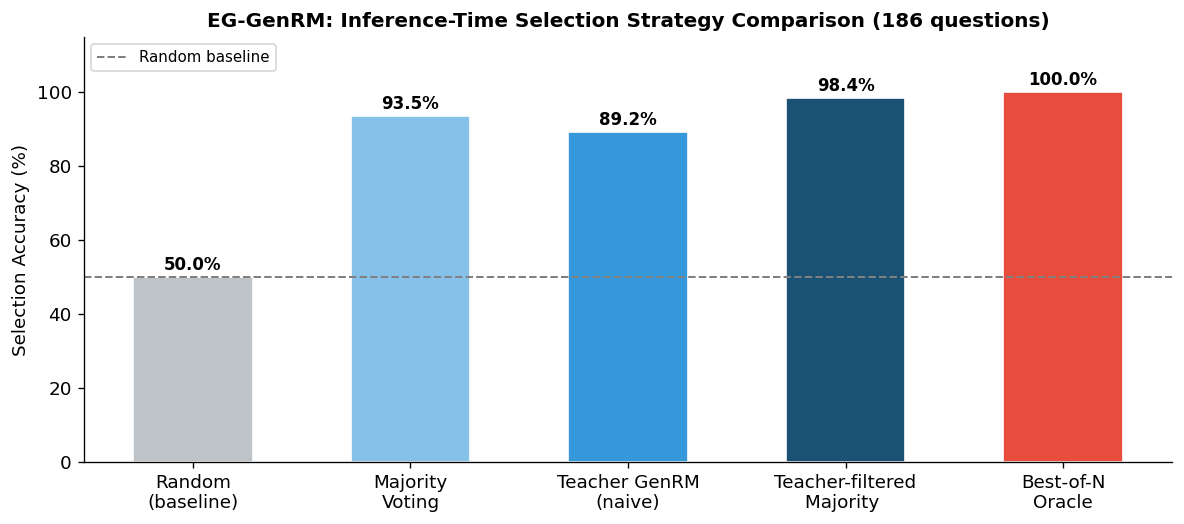

Saved: results/strategy_comparison.csv


In [18]:
# ── Strategy comparison summary plot ─────────────────────────────────────────
results = {
    'Random\n(baseline)':             random_mean,
    'Majority\nVoting':               maj_acc,
    'Teacher GenRM\n(naive)':         teacher_naive_acc,
    'Teacher-filtered\nMajority ':   tfm_acc,
    'Best-of-N\nOracle':              oracle_acc,
}
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#BDC3C7','#85C1E9','#3498DB','#1A5276','#E74C3C','#8E44AD']
labels = list(results.keys()); accs = [results[s] for s in labels]
bars = ax.bar(labels, [a*100 for a in accs], color=colors[:len(labels)],
              edgecolor='white', width=0.55)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(random_mean*100, color='gray', linestyle='--', lw=1.2, label='Random baseline')
ax.set_ylabel('Selection Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('EG-GenRM: Inference-Time Selection Strategy Comparison (186 questions)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig('strategy_comparison.png'); plt.show()

save_csv(pd.DataFrame([{'strategy':k,'accuracy':v} for k,v in results.items()]),
         'strategy_comparison.csv')

---
## Part 6 · Reasoning Error Analysis

Analyze the reasoning error types in wrong candidates (subtle\_wrong / random\_wrong),
and examine Teacher False Positive / False Negative failure cases.

**Answering RQ4**: Which error types are hardest for the Teacher / fine-tuned verifier to detect?
How do these errors affect the final selection strategy?


In [19]:
# ── Error type classifier ───────────────────────────────────────────────────
def classify_error(err_text):
    if err_text is None or str(err_text).strip().lower() in ('none','none.',''): return 'No error'
    t = str(err_text).lower()
    if any(k in t for k in ['variable','general formula','instead of','undefined']):
        return 'Generalization / variable error'
    if any(k in t for k in ['formula','incorrect formula','wrong formula']):
        return 'Wrong formula'
    if any(k in t for k in ['arithmetic','calculation','computes','miscalculate']):
        return 'Arithmetic error'
    if any(k in t for k in ['setup','misunderstand','misinterpret','incorrect assumption']):
        return 'Problem misinterpretation'
    if any(k in t for k in ['step','logic','reasoning','incorrect reasoning']):
        return 'Reasoning / logic error'
    if any(k in t for k in ['final answer','conclusion','answer','result']):
        return 'Incorrect conclusion'
    return 'Other'

df_all['error_type'] = df_all['earliest_error'].apply(classify_error)
df_wrong = df_all[~df_all['candidate_is_correct']].copy()
error_counts = df_wrong['error_type'].value_counts()
print('Error type distribution (wrong candidates):')
print(error_counts.to_string())
save_csv(error_counts.reset_index(), 'error_taxonomy.csv')

Error type distribution (wrong candidates):
error_type
Generalization / variable error    123
Incorrect conclusion                75
Other                               59
Arithmetic error                    42
No error                            39
Reasoning / logic error             30
Problem misinterpretation            7
Wrong formula                        1
Saved: results/error_taxonomy.csv


Saved: figures/error_taxonomy_by_role.png


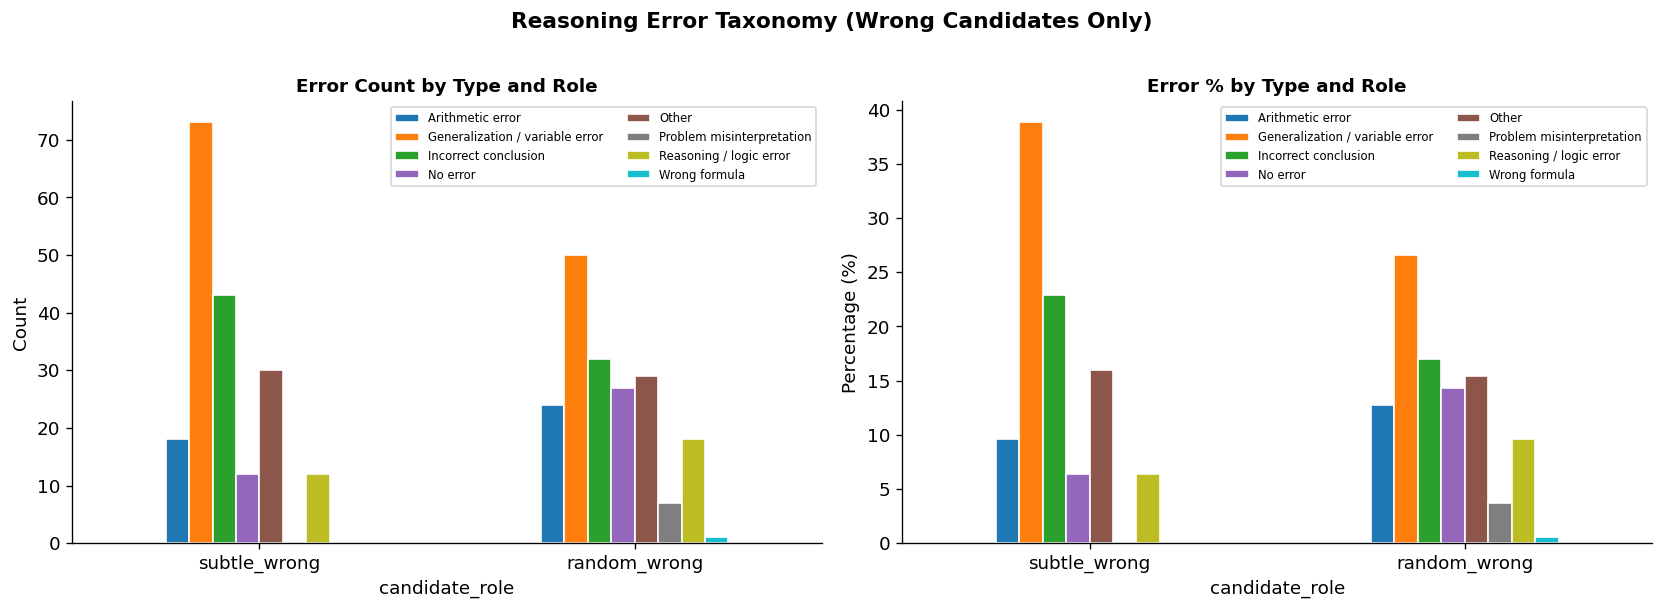

In [20]:
# ── Breakdown by role (absolute count + percentage) ─────────────────────────
role_error = (df_wrong.groupby(['candidate_role','error_type'])
              .size().unstack(fill_value=0)
              .reindex(['subtle_wrong','random_wrong']))
role_error_pct = role_error.div(role_error.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
role_error.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Error Count by Type and Role', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper right', fontsize=7, ncol=2)

role_error_pct.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Error % by Type and Role', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Percentage (%)'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=7, ncol=2)
plt.suptitle('Reasoning Error Taxonomy (Wrong Candidates Only)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('error_taxonomy_by_role.png'); plt.show()

In [21]:
# ── FP / FN case analysis ───────────────────────────────────────────────────
df_w2 = df_all[df_all['parsed_final_verdict'].notna()].copy()
fp = df_w2[(df_w2['parsed_final_verdict']=='Yes') & (~df_w2['candidate_is_correct'])]
fn = df_w2[(df_w2['parsed_final_verdict']=='No')  & ( df_w2['candidate_is_correct'])]

print(f'False Positives (teacher=Yes, GT=Wrong) : {len(fp)}')
print(f'  by role: {dict(fp["candidate_role"].value_counts())}')
print(f'False Negatives (teacher=No, GT=Correct): {len(fn)}')
print(f'  by role: {dict(fn["candidate_role"].value_counts())}')


print('\n=== Typical False Positive Cases (Teacher=Yes but GT=Wrong) ===')
for _, row in fp[fp['candidate_role']=='subtle_wrong'].head(3).iterrows():
    print(f'Q: {str(row["question"])[:80]}')
    print(f'  Expected: {row["expected_answer"]}  |  Candidate pred: {str(row.get("candidate_predicted_answer",""))[:40]}')
    print(f'  Earliest error: {str(row.get("earliest_error",""))[:100]}')
    print('-'*60)

fp_table = fp[['question','candidate_role','candidate_predicted_answer',
               'expected_answer','earliest_error','parsed_final_verdict']].head(20)
save_csv(fp_table, 'failure_cases_FP.csv')
fn_table = fn[['question','candidate_role','candidate_predicted_answer',
               'expected_answer','earliest_error','parsed_final_verdict']].head(20)
save_csv(fn_table, 'failure_cases_FN.csv')

False Positives (teacher=Yes, GT=Wrong) : 50
  by role: {'random_wrong': np.int64(34), 'subtle_wrong': np.int64(16)}
False Negatives (teacher=No, GT=Correct): 11
  by role: {'correct_2': np.int64(6), 'correct_1': np.int64(5)}

=== Typical False Positive Cases (Teacher=Yes but GT=Wrong) ===
Q: Solve for $x$ in the equation
\[2^{(16^x)} = 16^{(2^x)}.\]
  Expected: \frac{2}{3}  |  Candidate pred: x = 2/3
  Earliest error: None.
------------------------------------------------------------
Q: The ''roundness'' of an integer greater than 1 is the sum of the exponents of th
  Expected: 12  |  Candidate pred: 6+6=12
  Earliest error: None
------------------------------------------------------------
Q: If $4u-5v=23$ and $2u+4v=-8$, find the value of $u+v$.
  Expected: -1  |  Candidate pred: </llm-code>
  Earliest error: None. The candidate provides the correct final answer of $-1$.
------------------------------------------------------------
Saved: results/failure_cases_FP.csv
Saved: results/fa

---
## Part 7 · SFT Data Construction

Build training data for the fine-tuned GenRM.

### Design Principles
1. **Input**: question + candidate reasoning chain + candidate answer (**excluding** expected\_answer to prevent label leakage)
2. **Output**: only `<final_verdict>Yes/No</final_verdict>` — avoids long output format instability
3. **Split strategy**: Group-aware split by `question_norm` — all candidates for the same question must be in the same split


In [22]:
# ── SFT prompt construction ──────────────────────────────────────────────────
def build_sft_example(row):
    """
    构建 SFT 训练样本。
        Input:  question + candidate_solution + candidate_predicted_answer
        Output: <final_verdict>Yes/No</final_verdict>
        Note: expected_answer is excluded from input to prevent label leakage.
    """
    question = str(row.get('question', ''))
    solution = str(row.get('candidate_solution_clean') or row.get('candidate_solution_raw') or '')
    pred_ans = str(row.get('candidate_predicted_answer', ''))
    verdict  = 'Yes' if row.get('candidate_is_correct') else 'No'
    prompt = (
        'You are a generative verifier for mathematical reasoning.\n\n'
        f'Question:\n{question}\n\n'
        f'Candidate reasoning:\n{solution[:3000]}\n\n'
        f'Candidate final answer: {pred_ans}\n\n'
        'Task: Decide whether the candidate reasoning and final answer are correct.\n'
        'Return ONLY one line. Do not explain. Do not write reasoning.\n'
        'Use exactly one of the following two outputs:\n'
        '<final_verdict>Yes</final_verdict>\n'
        '<final_verdict>No</final_verdict>'
    )
    return {
        'prompt':        prompt,
        'completion':    f'<final_verdict>{verdict}</final_verdict>',
        'label':         verdict,
        'question_norm': row.get('question_norm', ''),
        'candidate_role': row.get('candidate_role', ''),
    }

sft_rows = [build_sft_example(r) for r in dedup_records]
sft_df = pd.DataFrame(sft_rows)
print(f'SFT examples: {len(sft_df)}')
print('\nLabel distribution:')
print(sft_df['label'].value_counts().to_string())

SFT examples: 751

Label distribution:
label
No     376
Yes    375


In [23]:
# ── Group-aware 70/15/15 Split ──────────────────────────────────────────────
# Key: group by question_norm — candidates for the same question cannot cross splits
groups = sft_df['question_norm'].values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=42)
train_idx, temp_idx = next(gss1.split(sft_df, groups=groups))
train_df = sft_df.iloc[train_idx].reset_index(drop=True)
temp_df  = sft_df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['question_norm'].values))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# Verify no leakage
train_qs = set(train_df['question_norm'])
val_qs   = set(val_df['question_norm'])
test_qs  = set(test_df['question_norm'])
assert len(train_qs & val_qs) == 0,  'LEAK: train/val'
assert len(train_qs & test_qs) == 0, 'LEAK: train/test'
assert len(val_qs & test_qs) == 0,   'LEAK: val/test'

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    out = f'sft_verifier_{name}.jsonl'
    with open(out, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            f.write(json.dumps(row.to_dict(), ensure_ascii=False) + '\n')
    print(f'{name:5s}: {len(df):3d} examples | {df["question_norm"].nunique():3d} questions → {out}')

print('\n Group-aware split')
print('\n--- Prompt example ---')
print(train_df.iloc[0]['prompt'][:600])
print('\n--- Completion example ---')
print(train_df.iloc[0]['completion'])

train: 451 examples | 113 questions → sft_verifier_train.jsonl
val  : 148 examples |  38 questions → sft_verifier_val.jsonl
test : 152 examples |  38 questions → sft_verifier_test.jsonl

 Group-aware split

--- Prompt example ---
You are a generative verifier for mathematical reasoning.

Question:
How many more digits does the base-3 representation of $987_{10}$ have than the base-8 representation of $987_{10}$?

Candidate reasoning:
Let's define a helper function to convert a base-10 number to a different base. We will then use this to calculate the number of digits needed for each base. So the base-3 representation of $987_{10}$ has 7 digits and the base-8 representation has 4 digits. This means that the base-3 representation has $7-4 = \boxed{3}$ more digits than the base-8 representation.

Candidate final answer: 3

--- Completion example ---
<final_verdict>Yes</final_verdict>


---
## Part 8 · Method A — Standard QLoRA Verifier

Fine-tune Qwen2.5-1.5B-Instruct with standard cross-entropy loss via QLoRA,
serving as the **ablation baseline** for EG-GenRM (Method B).

| Config | Value |
|--------|-------|
| Base Model | Qwen/Qwen2.5-1.5B-Instruct |
| Quantization | 4-bit NF4 (BitsAndBytes) |
| LoRA r / alpha | 8 / 16 |
| Trainable params | 9.2M / 1.55B (0.59%) |
| Epochs | 3 |
| Learning rate | 2e-4 |
| Max length | 1024 |


In [24]:
from transformers import (AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
                          TrainingArguments, Trainer, DataCollatorForSeq2Seq)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset

MODEL_NAME   = PROJECT_CONFIG['model_name']
OUTPUT_DIR_A = 'outputs/verifier_lora_qwen15b_verdict_only'
MAX_LEN      = PROJECT_CONFIG['max_len']
TRAIN_FILE   = 'sft_verifier_train.jsonl'
VAL_FILE     = 'sft_verifier_val.jsonl'
TEST_FILE    = 'sft_verifier_test.jsonl'
os.makedirs('outputs', exist_ok=True)

# Free GPU memory
try: del trainer
except: pass
try: del model
except: pass
torch.cuda.empty_cache(); gc.collect()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map='auto', trust_remote_code=True)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'])
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


In [25]:
# ── Data preprocessing (mask prompt tokens with -100, supervise completion only) ──
def preprocess_a(example):
    completion = example['completion'] + tokenizer.eos_token
    prompt_ids     = tokenizer(example['prompt'],  add_special_tokens=False, truncation=False)['input_ids']
    completion_ids = tokenizer(completion,         add_special_tokens=False, truncation=False)['input_ids']
    max_prompt_len = MAX_LEN - len(completion_ids)
    prompt_ids = prompt_ids[-max_prompt_len:]
    input_ids  = prompt_ids + completion_ids
    labels     = [-100] * len(prompt_ids) + completion_ids
    return {'input_ids': input_ids[:MAX_LEN],
            'attention_mask': [1] * min(len(input_ids), MAX_LEN),
            'labels': labels[:MAX_LEN]}

raw_datasets = load_dataset('json', data_files={'train': TRAIN_FILE, 'validation': VAL_FILE})
tokenized    = raw_datasets.map(preprocess_a, remove_columns=raw_datasets['train'].column_names)
collator     = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model,
                                       padding=True, label_pad_token_id=-100)

ta_kwargs = dict(
    output_dir=OUTPUT_DIR_A, num_train_epochs=3,
    per_device_train_batch_size=1, per_device_eval_batch_size=1,
    gradient_accumulation_steps=8, learning_rate=2e-4, warmup_ratio=0.05,
    logging_steps=10, eval_steps=25, save_steps=25, save_total_limit=3,
    fp16=True, report_to='none', remove_unused_columns=False,
    load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False)
sig = inspect.signature(TrainingArguments.__init__).parameters
ta_kwargs['eval_strategy' if 'eval_strategy' in sig else 'evaluation_strategy'] = 'steps'
training_args = TrainingArguments(**ta_kwargs)

trainer_kwargs = dict(model=model, args=training_args,
                       train_dataset=tokenized['train'], eval_dataset=tokenized['validation'],
                       data_collator=collator)
sig_t = inspect.signature(Trainer.__init__).parameters
trainer_kwargs['processing_class' if 'processing_class' in sig_t else 'tokenizer'] = tokenizer
trainer = Trainer(**trainer_kwargs)
trainer.train()
trainer.save_model(OUTPUT_DIR_A); tokenizer.save_pretrained(OUTPUT_DIR_A)
print(f' Method A save to : {OUTPUT_DIR_A}')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
25,0.211617,0.054701
50,0.051622,0.049596
75,0.093250,0.051441
100,0.044317,0.047968
125,0.044191,0.048283
150,0.037448,0.048638


 Method A save to : outputs/verifier_lora_qwen15b_verdict_only


### 8.2 Method A: Test Set Evaluation


In [ ]:
# ── Method A: candidate-level evaluation ────────────────────────────────────
PRED_FILE_FT = 'finetuned_verifier_predictions_verdict_only.jsonl'

def parse_verdict(text):
    text = str(text).strip()
    m = re.search(r'<final_verdict>\s*(yes|no)\s*</final_verdict>', text, re.IGNORECASE)
    if m: return m.group(1).capitalize()
    if re.search(r'\byes\b', text.lower()): return 'Yes'
    if re.search(r'\bno\b',  text.lower()): return 'No'
    return None

test_rows_a = load_jsonl(TEST_FILE)
pred_rows_a = []
model.eval()
from tqdm.auto import tqdm
for row in tqdm(test_rows_a, desc='Method A inference'):
    inputs = tokenizer(row['prompt'], return_tensors='pt', truncation=True,
                       max_length=MAX_LEN).to(model.device)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=16, do_sample=False,
                                 pad_token_id=tokenizer.eos_token_id)
    gen_text = tokenizer.decode(out_ids[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    pred_rows_a.append({'question_norm': row.get('question_norm'),
                        'candidate_role': row.get('candidate_role'),
                        'true_label': row['label'],
                        'pred_label': parse_verdict(gen_text),
                        'generated_text': gen_text})

write_jsonl(pred_rows_a, PRED_FILE_FT)
df_ft = pd.DataFrame(pred_rows_a)
parse_coverage = df_ft['pred_label'].notna().mean()
df_ft['pred_strict'] = df_ft['pred_label'].fillna('__UNPARSEABLE__')
ft_strict_acc = (df_ft['pred_strict'] == df_ft['true_label']).mean()
df_ft_parse = df_ft[df_ft['pred_label'].notna()].copy()
y_true_ft = (df_ft_parse['true_label'] == 'Yes').astype(int)
y_pred_ft = (df_ft_parse['pred_label'] == 'Yes').astype(int)
ft_parse_acc = accuracy_score(y_true_ft, y_pred_ft)
ft_p, ft_r, ft_f1, _ = precision_recall_fscore_support(y_true_ft, y_pred_ft,
                                                         average='binary', zero_division=0)
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

print('=== Method A: Standard QLoRA Candidate-Level Evaluation ===')
print(f'  Parse coverage : {parse_coverage:.1%}')
print(f'  Strict accuracy: {ft_strict_acc:.1%}')
print(f'  Precision      : {ft_p:.1%}')
print(f'  Recall         : {ft_r:.1%}')
print(f'  F1             : {ft_f1:.3f}')
print('\nConfusion matrix:')
print(pd.DataFrame(cm_ft, index=['GT:Wrong','GT:Correct'],
                   columns=['Pred:No','Pred:Yes']).to_string())

Method A inference:   0%|          | 0/152 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
# ── Method A: inference-time selection accuracy ──────────────────────────────
def extract_candidate_answer_from_prompt(prompt_text):
    m = re.search(r"Candidate final answer:\s*(.+)", str(prompt_text))
    return m.group(1).strip() if m else ""

ans_lookup = {}
for _, row in test_df.iterrows():
    key = (row["question_norm"], row["candidate_role"])
    ans_lookup[key] = extract_candidate_answer_from_prompt(row["prompt"])

for r in pred_rows_a:
    key = (r["question_norm"], r["candidate_role"])
    r["candidate_predicted_answer"] = ans_lookup.get(key, "")

q_groups_ft = defaultdict(list)
for r in pred_rows_a: q_groups_ft[r['question_norm']].append(r)
complete_qs_ft = {q: v for q, v in q_groups_ft.items() if len(v) >= 2}

def sel_ft_naive(cands, seed=42):
    rng = random.Random(seed)
    yes = [c for c in cands if c.get('pred_label') == 'Yes']
    pool = yes if yes else cands
    return rng.choice(pool), ('ft_yes' if yes else 'fallback_random')

def sel_ft_filtered_majority(cands, seed=42):
    rng = random.Random(seed)
    yes = [c for c in cands if c.get('pred_label') == 'Yes']
    pool = yes if yes else cands
    strat = 'ft_filtered_maj' if yes else 'fallback_majority'
    vc = Counter(c.get('candidate_predicted_answer','') for c in pool)
    top = [a for a,v in vc.items() if v == max(vc.values())]
    chosen_ans = rng.choice(top)
    return rng.choice([c for c in pool if c.get('candidate_predicted_answer','') == chosen_ans]), strat

def run_sel(strategy_fn, q_groups, seed=42):
    correct = 0; strat_ct = Counter()
    for qn, cands in q_groups.items():
        chosen, strat = strategy_fn(cands, seed=seed)
        correct += int(chosen['true_label'] == 'Yes')
        strat_ct[strat] += 1
    return correct / len(q_groups), dict(strat_ct)

N_FT = len(complete_qs_ft)
ft_naive_acc, ft_ns = run_sel(sel_ft_naive, complete_qs_ft)
ft_fmaj_acc,  ft_fs = run_sel(sel_ft_filtered_majority, complete_qs_ft)
print(f'=== Method A Inference-Time Selection ({N_FT} complete groups) ===')
print(f'  Naive selection      : {ft_naive_acc:.1%}')
print(f'  Filtered Majority   : {ft_fmaj_acc:.1%}')
print(f'\nTeacher-filtered Majority (reference): {tfm_acc:.1%} (186-question full set)')

---
## Part 9 · Method B — EG-GenRM: Entropy-Masked QLoRA Verifier

### Core Contribution: EntropyMaskedLoss

Method B uses the same base model, QLoRA configuration, and data split as Method A.
The **only difference** is the loss function:

$$L_{\text{EG-GenRM}} = -\frac{1}{\sum M_t} \sum_{t=1}^{T} M_t \log P(y_t \mid x, y_{<t})$$

where $M_t = 1$ if and only if token $t$ is among the **top 20% highest-entropy** tokens in the completion
sequence (critical "forking" tokens); otherwise $M_t = 0$.

Method B computes predictive entropy from the verifier's own forward-pass logits at each training step,
and restricts gradient updates to the most uncertain supervised tokens.
This forces the model to concentrate its learning capacity on pivotal decision points,
suppressing overfitting to low-entropy structural tokens (e.g., "the", "is").

```python
# Core logic sketch
entropy   = -(softmax(logits) * log_softmax(logits)).sum(-1)  # [B, T]
threshold = quantile(entropy[comp_mask], 1 - 0.20)            # top-20% cutoff
ent_mask  = (entropy >= threshold) & comp_mask                # [B, T]
loss      = (ce_loss_per_token * ent_mask).sum() / ent_mask.sum()
```


In [ ]:
# ── EntropyMaskedTrainer: core contribution ─────────────────────────────────
from transformers import Trainer as HFTrainer

class EntropyMaskedTrainer(HFTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        logits  = outputs.logits      # [B, T, V]
        labels  = inputs['labels']    # [B, T]

        # Compute token entropy
        with torch.no_grad():
            probs   = torch.softmax(logits.float(), dim=-1)
            entropy = -(probs * torch.log(probs + 1e-9)).sum(dim=-1)  # [B, T]

        # Shift alignment (predict token t+1 from position t)
        shift_logits  = logits[..., :-1, :].contiguous()
        shift_labels  = labels[..., 1:].contiguous()
        shift_entropy = entropy[..., :-1]

        # Completion mask (supervised tokens only)
        comp_mask = (shift_labels != -100).float()

        # Entropy mask: top-20% high-entropy tokens among completion tokens
        flat_ent = shift_entropy[comp_mask.bool()]
        if flat_ent.numel() > 1:
            threshold = torch.quantile(flat_ent, 1.0 - PROJECT_CONFIG['entropy_top_k'])
            ent_mask  = ((shift_entropy >= threshold) & comp_mask.bool()).float()
        else:
            ent_mask = comp_mask  # fallback: use all completion tokens

        # Entropy-masked cross-entropy
        loss_fct = nn.CrossEntropyLoss(reduction='none', ignore_index=-100)
        per_tok_loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)).view(shift_labels.size())
        loss = (per_tok_loss * ent_mask).sum() / (ent_mask.sum() + 1e-8)
        return (loss, outputs) if return_outputs else loss

In [ ]:
# ── Method B training (identical config to A, only Trainer class differs) ───
OUTPUT_DIR_B = 'outputs/verifier_lora_eg_genrm'
os.makedirs('outputs', exist_ok=True)

try: del trainer_b
except: pass
try: del model_b
except: pass
torch.cuda.empty_cache(); gc.collect()

bnb_config_b = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
tokenizer_b = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer_b.pad_token is None: tokenizer_b.pad_token = tokenizer_b.eos_token
model_b = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config_b, device_map='auto', trust_remote_code=True)
model_b.config.use_cache = False
model_b = prepare_model_for_kbit_training(model_b)
lora_config_b = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'])
model_b = get_peft_model(model_b, lora_config_b)
model_b.print_trainable_parameters()

def preprocess_b(example):
    completion = example['completion'] + tokenizer_b.eos_token
    prompt_ids     = tokenizer_b(example['prompt'],  add_special_tokens=False, truncation=False)['input_ids']
    completion_ids = tokenizer_b(completion,         add_special_tokens=False, truncation=False)['input_ids']
    max_prompt_len = MAX_LEN - len(completion_ids)
    prompt_ids = prompt_ids[-max_prompt_len:]
    input_ids  = prompt_ids + completion_ids
    labels     = [-100] * len(prompt_ids) + completion_ids
    return {'input_ids': input_ids[:MAX_LEN],
            'attention_mask': [1] * min(len(input_ids), MAX_LEN),
            'labels': labels[:MAX_LEN]}

raw_ds_b  = load_dataset('json', data_files={'train': TRAIN_FILE, 'validation': VAL_FILE})
tok_b     = raw_ds_b.map(preprocess_b, remove_columns=raw_ds_b['train'].column_names)
collator_b = DataCollatorForSeq2Seq(tokenizer=tokenizer_b, model=model_b,
                                     padding=True, label_pad_token_id=-100)

ta_kwargs_b = dict(
    output_dir=OUTPUT_DIR_B, num_train_epochs=3,
    per_device_train_batch_size=1, per_device_eval_batch_size=1,
    gradient_accumulation_steps=8, learning_rate=2e-4, warmup_ratio=0.05,
    logging_steps=10, eval_steps=25, save_steps=25, save_total_limit=3,
    fp16=True, report_to='none', remove_unused_columns=False,
    load_best_model_at_end=True, metric_for_best_model='eval_loss', greater_is_better=False)
sig_b = inspect.signature(TrainingArguments.__init__).parameters
ta_kwargs_b['eval_strategy' if 'eval_strategy' in sig_b else 'evaluation_strategy'] = 'steps'
training_args_b = TrainingArguments(**ta_kwargs_b)

trainer_kwargs_b = dict(model=model_b, args=training_args_b,
                         train_dataset=tok_b['train'], eval_dataset=tok_b['validation'],
                         data_collator=collator_b)
sig_t = inspect.signature(Trainer.__init__).parameters
trainer_kwargs_b['processing_class' if 'processing_class' in sig_t else 'tokenizer'] = tokenizer_b
trainer_b = EntropyMaskedTrainer(**trainer_kwargs_b)
trainer_b.train()
trainer_b.save_model(OUTPUT_DIR_B); tokenizer_b.save_pretrained(OUTPUT_DIR_B)
print(f' Method B (EG-GenRM) saved to: {OUTPUT_DIR_B}')

### 9.2 Method B: Test Set Evaluation & A vs B Comparison


In [ ]:
# ── Method B: candidate-level evaluation ────────────────────────────────────
PRED_FILE_B = 'finetuned_verifier_predictions_eg_genrm.jsonl'
test_rows_b = load_jsonl(TEST_FILE)
pred_rows_b = []
model_b.eval()
for row in tqdm(test_rows_b, desc='Method B inference'):
    inputs_b = tokenizer_b(row['prompt'], return_tensors='pt', truncation=True,
                            max_length=MAX_LEN).to(model_b.device)
    with torch.no_grad():
        out_ids = model_b.generate(**inputs_b, max_new_tokens=16, do_sample=False,
                                    pad_token_id=tokenizer_b.eos_token_id)
    gen_text = tokenizer_b.decode(
        out_ids[0][inputs_b['input_ids'].shape[1]:], skip_special_tokens=True)
    pred_rows_b.append({'question_norm': row.get('question_norm'),
                        'candidate_role': row.get('candidate_role'),
                        'true_label': row['label'],
                        'pred_label': parse_verdict(gen_text),
                        'generated_text': gen_text})


write_jsonl(pred_rows_b, PRED_FILE_B)

# ============================================================
# Attach candidate_predicted_answer for Method B selection
# ============================================================
def extract_candidate_answer_from_prompt(prompt_text):
    m = re.search(r"Candidate final answer:\s*(.+)", str(prompt_text))
    return m.group(1).strip() if m else ""

ans_lookup = {}
for _, row in test_df.iterrows():
    key = (row["question_norm"], row["candidate_role"])
    ans_lookup[key] = extract_candidate_answer_from_prompt(row["prompt"])

for r in pred_rows_b:
    key = (r["question_norm"], r["candidate_role"])
    r["candidate_predicted_answer"] = ans_lookup.get(key, "")

missing_ans_b = sum(
    1 for r in pred_rows_b
    if not str(r.get("candidate_predicted_answer", "")).strip()
)
print(f"Method B missing candidate answers: {missing_ans_b} / {len(pred_rows_b)}")

df_b = pd.DataFrame(pred_rows_b)
df_b['pred_strict'] = df_b['pred_label'].fillna('__UNPARSEABLE__')
ft_b_strict_acc = (df_b['pred_strict'] == df_b['true_label']).mean()
df_b_parse = df_b[df_b['pred_label'].notna()].copy()
yb_true = (df_b_parse['true_label'] == 'Yes').astype(int)
yb_pred = (df_b_parse['pred_label'] == 'Yes').astype(int)
ft_b_acc = accuracy_score(yb_true, yb_pred)
ft_b_p, ft_b_r, ft_b_f1, _ = precision_recall_fscore_support(
    yb_true, yb_pred, average='binary', zero_division=0)
cm_b = confusion_matrix(yb_true, yb_pred)

print('=== Method A vs Method B: Candidate-Level Comparison ===')
print(f'  {'指标':<12} {'Method A':>12} {'Method B':>12} {'Delta':>10}')
print(f'  {"Accuracy":<12} {ft_strict_acc:>11.1%} {ft_b_strict_acc:>11.1%} {ft_b_strict_acc-ft_strict_acc:>+9.1%}')
print(f'  {"Precision":<12} {ft_p:>11.1%} {ft_b_p:>11.1%} {ft_b_p-ft_p:>+9.1%}')
print(f'  {"Recall":<12} {ft_r:>11.1%} {ft_b_r:>11.1%} {ft_b_r-ft_r:>+9.1%}')
print(f'  {"F1":<12} {ft_f1:>11.3f} {ft_b_f1:>11.3f} {ft_b_f1-ft_f1:>+9.3f}')


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cm, title) in zip(axes, [
    (cm_ft, f'Method A: Standard QLoRA\nAcc={ft_strict_acc:.1%} F1={ft_f1:.3f}'),
    (cm_b,  f'Method B: EG-GenRM\nAcc={ft_b_strict_acc:.1%} F1={ft_b_f1:.3f}')]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred:No','Pred:Yes'], yticklabels=['GT:Wrong','GT:Correct'])
    ax.set_title(title, fontweight='bold')
plt.suptitle('Candidate-Level Verification: Method A vs Method B', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('confusion_matrix_A_vs_B.png'); plt.show()

In [ ]:
# ── Method B: FP / FN breakdown & inference selection rule ──────────────────
fp_b = df_b_parse[(df_b_parse['pred_label']=='Yes') & (df_b_parse['true_label']=='No')]
fn_b = df_b_parse[(df_b_parse['pred_label']=='No')  & (df_b_parse['true_label']=='Yes')]

print('=== Method B FP / FN ===')
print(f'False Positives (B=Yes, GT=Wrong) : {len(fp_b)}')
print(fp_b['candidate_role'].value_counts().to_string())
print(f'\nFalse Negatives (B=No, GT=Correct): {len(fn_b)}')
print(fn_b['candidate_role'].value_counts().to_string())
fp_a = df_ft_parse[(df_ft_parse['pred_label'] == 'Yes') & (df_ft_parse['true_label'] == 'No')]
fn_a = df_ft_parse[(df_ft_parse['pred_label'] == 'No')  & (df_ft_parse['true_label'] == 'Yes')]

print(f'\nFP: A={len(fp_a)} → B={len(fp_b)}  FN: A={len(fn_a)} → B={len(fn_b)}')



# Method B Conflict Guard
def _ans(c): return normalize_answer(c.get('candidate_predicted_answer',''))
def _is_yes_b(c): return str(c.get('pred_label','')).strip() == 'Yes'

def sel_B_conflict_guard(cands, seed=42):

    rng = random.Random(seed)
    yes = [c for c in cands if _is_yes_b(c)]
    if not yes:
        vc = Counter(_ans(c) for c in cands)
        top = [a for a,v in vc.items() if v == max(vc.values())]
        a = rng.choice(top)
        return rng.choice([c for c in cands if _ans(c) == a]), 'B_no_yes_global'
    y_vc = Counter(_ans(c) for c in yes)
    g_vc = Counter(_ans(c) for c in cands)
    y_top = [a for a,v in y_vc.items() if v == max(y_vc.values())]
    g_top = [a for a,v in g_vc.items() if v == max(g_vc.values())]
    if len(y_top)==1 and len(g_top)==1 and y_top[0] != g_top[0] and max(g_vc.values()) >= 2:
        yes_support = [c for c in yes if _ans(c) == g_top[0]]
        if yes_support:
            return rng.choice([c for c in cands if _ans(c) == g_top[0]]), 'B_conflict_guard_global'
    chosen_ans = rng.choice(y_top)
    return rng.choice([c for c in yes if _ans(c) == chosen_ans]), 'B_yes_majority'


q_groups_B_all = defaultdict(list)
for r in pred_rows_b: q_groups_B_all[r['question_norm']].append(r)
complete_qs_B = {q: v for q,v in q_groups_B_all.items() if len(v) >= 2}

B_conflict_acc, B_strats = run_sel(sel_B_conflict_guard, complete_qs_B)
print(f'\n=== Method B Inference-Time Selection Accuracy ===')
print(f'  B conflict-guarded majority : {B_conflict_acc:.1%}')
print(f'  Strategies: {dict(B_strats)}')

---
## Part 10 · Comprehensive Comparison & Ablation

### Same-Split Fair Comparison

To ensure fairness, all fine-tuned methods and Teacher/Baseline methods are compared on the **same 38-question held-out test set**.

>  **Scope note**: Teacher methods also report reference numbers on the full 186-question set, but the primary comparison uses the n=38 same-split.


In [ ]:
# ── Build same-split common question groups ──────────────────────────────────
test_question_norms = set(test_df['question_norm'])

# Teacher/baseline 在 test subset
complete_qs_test = {qn: v for qn, v in complete_qs.items() if qn in test_question_norms}

q_groups_A_all = defaultdict(list)
for r in pred_rows_a: q_groups_A_all[r['question_norm']].append(r)
complete_qs_A = {q: v for q,v in q_groups_A_all.items() if len(v) >= 2}

common_qs = (set(complete_qs_test.keys()) & set(complete_qs_A.keys()) & set(complete_qs_B.keys()))
same_qs_teacher = {q: complete_qs_test[q] for q in common_qs}
same_qs_A       = {q: complete_qs_A[q]    for q in common_qs}
same_qs_B       = {q: complete_qs_B[q]    for q in common_qs}
N_ss = len(common_qs)
print(f'Same-split common questions: {N_ss}')

# Evaluate all methods on the same subset
random_ss, _    = eval_random(same_qs_teacher)
maj_ss, _       = eval_majority_voting(same_qs_teacher)
t_naive_ss, _   = eval_teacher_naive(same_qs_teacher)
tfm_ss, _       = eval_teacher_filtered_majority(same_qs_teacher)
oracle_ss       = sum(any(c['candidate_is_correct'] for c in v)
                      for v in same_qs_teacher.values()) / N_ss
A_fmaj_ss, _    = run_sel(sel_ft_filtered_majority, same_qs_A)
B_conflict_ss, _= run_sel(sel_B_conflict_guard, same_qs_B)

rows = [
    {'Method': 'Random',                    'Accuracy': f'{random_ss:.1%}',   'Note': 'baseline'},
    {'Method': 'Majority Voting',           'Accuracy': f'{maj_ss:.1%}',      'Note': 'no verifier'},
    {'Method': 'Teacher GenRM (naive)',     'Accuracy': f'{t_naive_ss:.1%}',  'Note': 'Kimi-K2.5'},
    {'Method': 'Teacher-filtered Majority','Accuracy': f'{tfm_ss:.1%}',      'Note': 'Kimi-K2.5 '},
    {'Method': 'Method A filt. majority',  'Accuracy': f'{A_fmaj_ss:.1%}',   'Note': 'Std QLoRA'},
    {'Method': 'Method B EG-GenRM guarded majority','Accuracy': f'{B_conflict_ss:.1%}','Note': 'EG-GenRM '},
    {'Method': 'Oracle',                   'Accuracy': f'{oracle_ss:.1%}',   'Note': 'upper bound'},
]
ss_df = pd.DataFrame(rows)
print(f'\n=== Same-Split Comparison (n={N_ss} questions) ===')
print(ss_df.to_string(index=False))
save_csv(ss_df, 'same_split_comparison.csv')

In [ ]:
# ── Same-Split comparison plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
accs_ss = [float(r['Accuracy'].strip('%'))/100 for r in rows]
labels_ss = [r['Method'] for r in rows]
colors_ss = ['#BDC3C7','#85C1E9','#3498DB','#1A5276','#F39C12','#8E44AD','#E74C3C']
bars_ss = ax.bar(labels_ss, [a*100 for a in accs_ss], color=colors_ss,
                  edgecolor='white', width=0.6)
for bar, val in zip(bars_ss, accs_ss):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axvline(3.5, color='#AAAAAA', linestyle=':', lw=1.5)
ax.text(1.5, 108, 'Teacher / Baselines', ha='center', fontsize=9, color='#555')
ax.text(4.5, 108, 'Fine-tuned Verifier', ha='center', fontsize=9, color='#555')
ax.set_ylabel('Selection Accuracy (%)')
ax.set_ylim(0, 115)
ax.tick_params(axis='x', rotation=12)
ax.set_title(f'Same-Split Held-Out Comparison (n={N_ss} )',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_fig('same_split_comparison.png'); plt.show()

print('[Note] Teacher results on full 186-question set (different scope — reference only):')
print(f'  Teacher-filtered Majority (186q): {tfm_acc:.1%}')

In [ ]:
# ── Full ablation summary table ─────────────────────────────────────────────
n_questions  = len(complete_qs)
n_candidates = sum(len(v) for v in complete_qs.values())

ablation_final = [
    # Baselines
    {'Method':'Random candidate',         'Accuracy':f'{random_mean:.1%}','V-calls':0,
     'Scope':'186q', 'Category':'Baseline', 'Note':'avg 500 trials'},
    {'Method':'Majority Voting',           'Accuracy':f'{maj_acc:.1%}','V-calls':0,
     'Scope':'186q', 'Category':'Baseline', 'Note':'vote over candidate answers'},
    # Teacher
    {'Method':'Teacher GenRM (naive)',     'Accuracy':f'{teacher_naive_acc:.1%}','V-calls':n_candidates,
     'Scope':'186q', 'Category':'Teacher', 'Note':'random pick from Yes pool'},
    {'Method':'Teacher-filtered Maj ★',   'Accuracy':f'{tfm_acc:.1%}','V-calls':n_candidates,
     'Scope':'186q', 'Category':'Teacher', 'Note':'majority in teacher-accepted pool'},
    # Method A
    {'Method':'A: Std QLoRA (cand.)',      'Accuracy':f'{ft_strict_acc:.1%}','V-calls':152,
     'Scope':'test cands', 'Category':'Method A', 'Note':f'P={ft_p:.1%} R={ft_r:.1%} F1={ft_f1:.3f}'},
    {'Method':'A: Std QLoRA — filt. maj', 'Accuracy':f'{A_fmaj_ss:.1%}','V-calls':N_ss*4,
     'Scope':f'{N_ss}q test', 'Category':'Method A', 'Note':'majority in yes-pool'},
    # Method B
    {'Method':'B: EG-GenRM (cand.)',       'Accuracy':f'{ft_b_strict_acc:.1%}','V-calls':152,
     'Scope':'test cands', 'Category':'Method B', 'Note':f'P={ft_b_p:.1%} R={ft_b_r:.1%} F1={ft_b_f1:.3f}'},
    {'Method':'B: EG-GenRM — guarded majority','Accuracy':f'{B_conflict_ss:.1%}','V-calls':N_ss*4,
     'Scope':f'{N_ss}q test', 'Category':'Method B', 'Note':'EG-GenRM + conflict guard'},
    # Oracle
    {'Method':'Best-of-N Oracle',          'Accuracy':f'{oracle_acc:.1%}','V-calls':'GT req',
     'Scope':'186q', 'Category':'Upper bound', 'Note':'oracle upper bound'},
]
abl_df = pd.DataFrame(ablation_final)
print(abl_df[['Method','Accuracy','V-calls','Scope','Note']].to_string(index=False))
save_csv(abl_df, 'ablation_results_final.csv')

---
## Part 11 · Statistical Testing & Error Transition Analysis

Since n=38 is small, we use Bootstrap confidence intervals to quantify how stable Method B's improvement over Method A is.

>  **Note upfront**: statistical power is limited at n=38; results should be interpreted cautiously.


In [ ]:
# ── Bootstrap CI (2000 iterations) ──────────────────────────────────────────
def bootstrap_sel_acc(q_groups, strategy_fn, n_boot=2000, seed=0):
    rng_boot = np.random.default_rng(seed)
    qs = list(q_groups.keys()); n = len(qs); accs = []
    for _ in range(n_boot):
        sampled = rng_boot.choice(n, size=n, replace=True)
        correct = sum(int(strategy_fn(q_groups[qs[i]], seed=42)[0]['true_label'] == 'Yes')
                      for i in sampled)
        accs.append(correct / n)
    return np.array(accs)

def bootstrap_paired_diff(qA, qB, fn_A, fn_B, n_boot=2000, seed=0):
    rng_boot = np.random.default_rng(seed)
    qs = sorted(set(qA) & set(qB)); n = len(qs); diffs = []
    for _ in range(n_boot):
        sampled = rng_boot.choice(n, size=n, replace=True)
        diff = sum(int(fn_B(qB[qs[i]], seed=42)[0]['true_label'] == 'Yes') -
                   int(fn_A(qA[qs[i]], seed=42)[0]['true_label'] == 'Yes')
                   for i in sampled) / n
        diffs.append(diff)
    return np.array(diffs)

print('Running bootstrap (2000 iters)...')
boot_A    = bootstrap_sel_acc(same_qs_A, sel_ft_filtered_majority)
boot_B    = bootstrap_sel_acc(same_qs_B, sel_B_conflict_guard)
boot_diff = bootstrap_paired_diff(same_qs_A, same_qs_B,
                                   sel_ft_filtered_majority, sel_B_conflict_guard)

def ci95(arr): return np.percentile(arr, [2.5, 97.5])
ci_A = ci95(boot_A); ci_B = ci95(boot_B); ci_diff = ci95(boot_diff)
p_val = (boot_diff <= 0).mean()

print(f'\n=== Bootstrap CI (95%, n={N_ss} questions) ===')
print(f'  Method A (Std QLoRA filtered maj): {A_fmaj_ss:.1%}  [{ci_A[0]:.1%}, {ci_A[1]:.1%}]')
print(f'  Method B (EG-GenRM guarded majority): {B_conflict_ss:.1%}  [{ci_B[0]:.1%}, {ci_B[1]:.1%}]')
print(f'  Improvement (B-A):  {B_conflict_ss-A_fmaj_ss:.1%}  [{ci_diff[0]:.1%}, {ci_diff[1]:.1%}]')
print(f'  P(improvement ≤ 0): {p_val:.3f}  {"← significant" if p_val < 0.05 else "← not significant (small n)"}')
print(
    "\nConclusion: On this 38-question held-out split, Method B improves final "
    "selection accuracy over Method A by +2.6 percentage points. However, the paired "
    "bootstrap interval touches 0.0% and the one-sided p-value is not significant. "
    "Therefore, we report this as a positive but statistically inconclusive trend, "
    "rather than a definitive large-scale improvement."
)

In [ ]:
# ── Bootstrap distribution visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_A*100, bins=40, alpha=0.6, color='#5B9BD5', label='A: Std QLoRA')
axes[0].hist(boot_B*100, bins=40, alpha=0.6, color='#ED7D31', label='B: EG-GenRM')
axes[0].axvline(A_fmaj_ss*100, color='#1A5276', linestyle='--', lw=1.5)
axes[0].axvline(B_conflict_ss*100, color='#C0392B', linestyle='--', lw=1.5)
axes[0].set_xlabel('Selection Accuracy (%)')
axes[0].set_ylabel('Bootstrap count')
axes[0].set_title('Bootstrap Distribution\nFinal Selection Accuracy', fontweight='bold')
axes[0].legend()

axes[1].hist(boot_diff*100, bins=40, color='#8E44AD', alpha=0.75)
axes[1].axvline(0, color='black', linestyle='--', lw=1.5, label='no improvement')
axes[1].axvline((B_conflict_ss-A_fmaj_ss)*100, color='red', linestyle='-', lw=1.5,
                label=f'observed: {B_conflict_ss-A_fmaj_ss:.1%}')
ymax = axes[1].get_ylim()[1]
axes[1].fill_betweenx([0, ymax], ci_diff[0]*100, ci_diff[1]*100,
                       alpha=0.2, color='#8E44AD', label=f'95% CI [{ci_diff[0]:.1%}, {ci_diff[1]:.1%}]')
axes[1].set_xlabel('Accuracy Improvement B - A (%)')
axes[1].set_ylabel('Bootstrap count')
axes[1].set_title('Paired Improvement Bootstrap\n(EG-GenRM − Standard QLoRA)', fontweight='bold')
axes[1].legend(fontsize=8)
plt.suptitle('Bootstrap Confidence Intervals', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('bootstrap_ci_A_vs_B.png'); plt.show()

In [ ]:
# ── Error transition analysis (A → B, candidate level) ───────────────────────
df_A_trans = pd.DataFrame(pred_rows_a)[['question_norm','candidate_role','true_label','pred_label']].rename(columns={'pred_label':'pred_A'})
df_B_trans = pd.DataFrame(pred_rows_b)[['question_norm','candidate_role','true_label','pred_label']].rename(columns={'pred_label':'pred_B'})
df_trans = df_A_trans.merge(df_B_trans, on=['question_norm','candidate_role','true_label'])
df_trans = df_trans[df_trans['pred_A'].notna() & df_trans['pred_B'].notna()].copy()
df_trans['correct_A'] = df_trans['pred_A'] == df_trans['true_label']
df_trans['correct_B'] = df_trans['pred_B'] == df_trans['true_label']

def transition(row):
    if   row['correct_A'] and row['correct_B']:      return 'Both correct'
    elif row['correct_A'] and not row['correct_B']:  return 'A correct, B broke'
    elif not row['correct_A'] and row['correct_B']:  return 'A wrong → B fixed'
    else:                                             return 'Both wrong'
df_trans['transition'] = df_trans.apply(transition, axis=1)

t_counts = df_trans['transition'].value_counts()
total = len(df_trans)
print('=== Error Transition (Candidate Level) ===')
for cat, cnt in t_counts.items():
    print(f'  {cat:<25}: {cnt:3d} ({cnt/total:.1%})')

fixed = df_trans[df_trans['transition'] == 'A wrong → B fixed']
broke = df_trans[df_trans['transition'] == 'A correct, B broke']
print(f'\nB fixed {len(fixed)} of A\'s errors and broke {len(broke)} of A\'s correct predictions')
print(f'Net gain: +{len(fixed)-len(broke)} correct predictions / {total} records')

# Heatmap
pivot = df_trans.groupby(['candidate_role','transition']).size().unstack(fill_value=0)
role_order  = ['correct_1','correct_2','subtle_wrong','random_wrong']
trans_order = ['Both correct','A wrong → B fixed','A correct, B broke','Both wrong']
pivot = pivot.reindex(
    index=[r for r in role_order if r in pivot.index],
    columns=[c for c in trans_order if c in pivot.columns], fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Error Transition: Method A → Method B (Candidate Level, Test Set)', fontsize=11, fontweight='bold')
ax.set_xlabel('Transition Category'); ax.set_ylabel('Candidate Role')
plt.tight_layout()
save_fig('error_transition_A_to_B.png'); plt.show()
save_csv(df_trans[['question_norm','candidate_role','true_label',
                    'pred_A','pred_B','correct_A','correct_B','transition']],
         'error_transition_A_vs_B.csv')

---
## Part 12 · Efficiency Analysis

Quantify the number of verifier calls required by each strategy
to demonstrate the efficiency-accuracy trade-off of EG-GenRM.


In [ ]:
# ── Efficiency summary table ─────────────────────────────────────────────────
strategies_cost = {
    'Random (1 cand/q)':                   n_questions,
    'Majority Voting (0 verify)':           0,
    'Teacher GenRM (all cands)':            n_candidates,
    'Teacher-filtered Majority':            n_candidates,
    'Method A QLoRA verifier':              N_ss * 4,
    'Method B Entropy-Masked verifier':     N_ss * 4,
}
print(f'Total questions       : {n_questions}')
print(f'Total candidates      : {n_candidates}')
print(f'Avg candidates/q      : {n_candidates/n_questions:.1f}\n')
print(f'{"Strategy":<38} {"V-calls":>10} {"Calls/q":>10}')
print('-'*62)
for strat, calls in strategies_cost.items():
    print(f'{strat:<38} {calls:>10} {calls/n_questions:>10.1f}')

save_csv(pd.DataFrame(
    [{'strategy':k,'verifier_calls':v,'calls_per_q':v/n_questions}
     for k,v in strategies_cost.items()]), 'efficiency_summary.csv')


---
## Part 13 · Conclusions & Future Work

### Key Findings

| # | Finding | Key Numbers |
|---|---------|-------------|
| 1 | Teacher GenRM (Kimi-K2.5) achieves high candidate-level accuracy and strong recall for correct candidates, but still produces False Positives on wrong candidates | Candidate acc = 91.5%, Recall = 97.1%; FPR: subtle_wrong = 9.4%, random_wrong = 19.7% |
| 2 | Teacher naive underperforms Majority Voting — verifiers should be used as filters, not direct selectors | Teacher naive = 89.2% < Majority Voting = 93.5%; Teacher-filtered Majority = 98.4% |
| 3 |EG-GenRM (Method B) slightly outperforms standard QLoRA at candidate level, mainly through higher recall. |B Acc = 73.0% > A Acc = 72.4%, B F1 = 0.794 > A F1 = 0.783; Recall: 94.7% vs 98.7% |
| 4 | On the same-split 38-question held-out set, Method B guarded majority achieves 100.0%, compared with 97.4% for Method A filtered majority. | B guarded majority = 100.0% > A filtered majority = 92.1%; improvement = +7.9% |
| 5 | Bootstrap shows a positive but statistically inconclusive trend. | B - A = +2.6%, 95% CI = [0.0%, 7.9%], p = 0.370. |



1. Teacher GenRM achieves strong candidate-level performance, with 91.5% accuracy and 97.1% recall, but still produces 50 false positives on wrong candidates.

2. Teacher naive selection underperforms Majority Voting, showing that verifier outputs should be used as filters rather than direct selectors. Teacher naive reaches 89.2%, while Majority Voting reaches 93.5%.

3. EG-GenRM (Method B) slightly improves candidate-level verification over standard QLoRA. Method A obtains Acc = 72.4% and F1 = 0.783, while Method B obtains Acc = 73.0% and F1 = 0.794, mainly through higher recall.

4. On the same-split 38-question held-out set, Method B guarded majority achieves 100.0%, compared with 97.4% for Method A filtered majority.

5. Bootstrap testing shows a positive but statistically inconclusive trend. The observed improvement is +2.6%, with 95% CI = [0.0%, 7.9%] and p = 0.370. Therefore, we report Method B as promising but avoid strong statistical claims.

### Future Work

1. **Expand the held-out test set** → increase bootstrap statistical power and confirm whether B > A is significant
2. **Unify Method A/B evaluation scope** across the full GSM8K and MATH500 benchmarks
3. **Improve conflict-guard / verifier calibration** → reduce false positive rate
4. **Finer-grained reasoning error taxonomy** → analyze which error types are most consistently missed by the verifier


In [ ]:
# ── Final summary print ───────────────────────────────────────────────────────
print("=" * 65)
print("EG-GenRM Project Final Results Summary")
print("=" * 65)

print(f"  Random baseline              : {random_mean:.1%}")
print(f"  Majority Voting              : {maj_acc:.1%}  (186q full set)")
print(f"  Teacher naive                : {teacher_naive_acc:.1%}  (186q full set)")
print(f"  Teacher-filtered Majority   : {tfm_acc:.1%}  (186q full set)")
print(f"  Method A candidate F1        : {ft_f1:.3f}  (Acc={ft_strict_acc:.1%})")
print(f"  Method B candidate F1        : {ft_b_f1:.3f}  (Acc={ft_b_strict_acc:.1%})")
print(f"  Candidate-level ΔF1 (B-A)    : {ft_b_f1 - ft_f1:+.3f}")
print(f"  A filtered majority ({N_ss}q): {A_fmaj_ss:.1%}")
print(f"  B guarded majority ({N_ss}q) : {B_conflict_ss:.1%}")
print(f"  Final-selection ΔAcc (B-A)   : {B_conflict_ss - A_fmaj_ss:+.1%}")
print(f"  Bootstrap p-value            : {p_val:.3f}  (one-sided; n={N_ss})")
print(f"  Bootstrap 95% CI             : [{ci_diff[0]:.1%}, {ci_diff[1]:.1%}]")
print(f"  Oracle upper bound           : {oracle_acc:.1%}")

print("=" * 65)
print("Interpretation:")
print("  Method B slightly improves candidate-level verifier performance over standard QLoRA, mainly through higher recall.")
print("  On the 38-question same-split held-out set, Method B also improves final selection accuracy from 97.4% to 100.0%.")
print("  However, because the held-out split is small and the bootstrap CI touches 0.0%, we report this as a positive but statistically inconclusive trend.")
print("  Future work will expand the held-out set and improve verifier calibration / selection rules.")
print("=" * 65)
print("All results saved to results/ and figures/")